In [1]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt

C:\Users\USER\Desktop\ai-fintech-platform\backend\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
X_train = pd.read_pickle("../../data/processed/X_train.pkl")
X_test = pd.read_pickle("../../data/processed/X_test.pkl")
y_test = pd.read_pickle("../../data/processed/y_test.pkl")

best_lgbm_model = joblib.load("../../ml/models/lightgbm_tuned.pkl")

print("Data and model loaded successfully.")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

Data and model loaded successfully.
X_train: (472432, 421)
X_test: (118108, 421)


In [3]:
#SHAP SAMPLE
X_shap_sample = X_test.sample(n=2000, random_state=42)

print("SHAP sample shape:", X_shap_sample.shape)

SHAP sample shape: (2000, 421)


In [4]:
# Create SHAP explainer
explainer = shap.TreeExplainer(best_lgbm_model)

shap_values = explainer.shap_values(X_shap_sample)

print("SHAP values calculated successfully.")

SHAP values calculated successfully.


C:\Users\USER\Desktop\ai-fintech-platform\backend\.venv\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


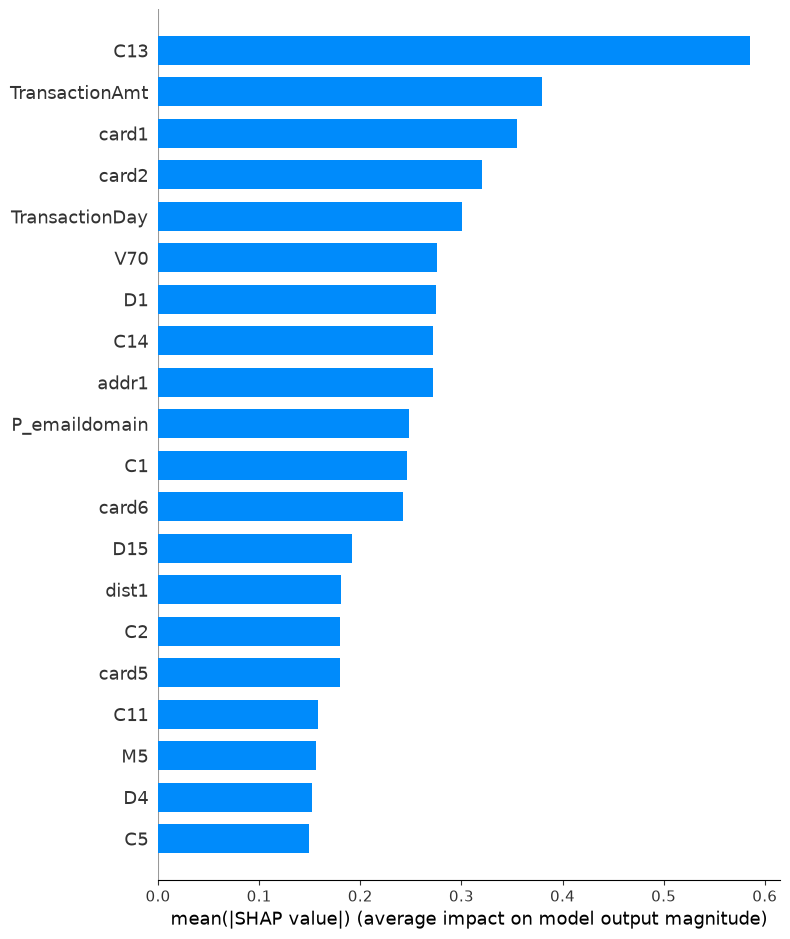

In [5]:
# Global SHAP summary plot
shap.summary_plot(
    shap_values,
    X_shap_sample,
    plot_type="bar",
    max_display=20
)

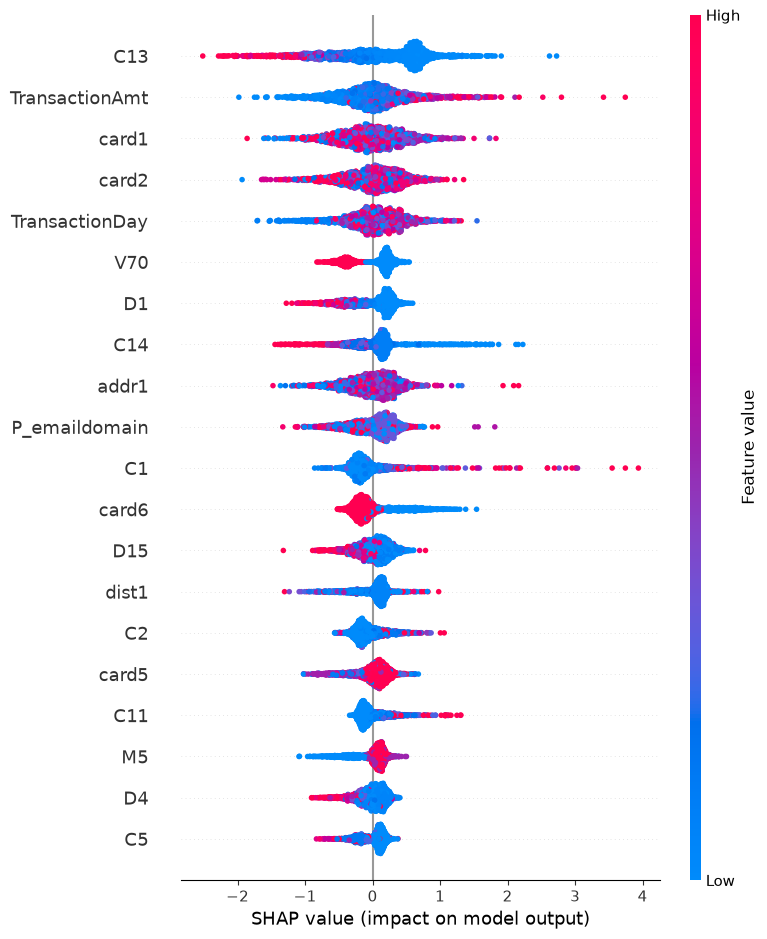

In [6]:
# Detailed SHAP beeswarm plot
shap.summary_plot(
    shap_values,
    X_shap_sample,
    max_display=20
)

In [7]:
# Pick one transaction from the SHAP sample
sample_index = 0

single_transaction = X_shap_sample.iloc[[sample_index]]
single_shap_values = explainer.shap_values(single_transaction)

print("Selected transaction index:", single_transaction.index[0])
print("Fraud probability:", best_lgbm_model.predict_proba(single_transaction)[0, 1])

C:\Users\USER\Desktop\ai-fintech-platform\backend\.venv\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


Selected transaction index: 434162
Fraud probability: 0.0015478855945094386


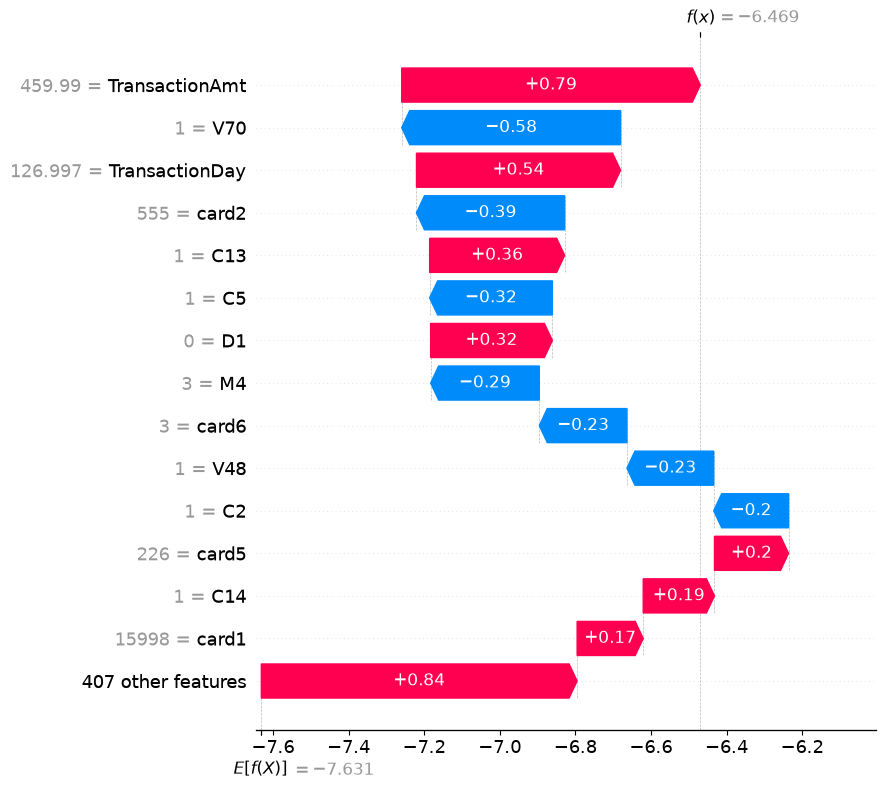

In [9]:
# Use SHAP values for the fraud class
if isinstance(single_shap_values, list):
    single_values = single_shap_values[1][0]
    base_value = explainer.expected_value[1]
else:
    single_values = single_shap_values[0]
    base_value = explainer.expected_value

shap.plots.waterfall(
    shap.Explanation(
        values=single_values,
        base_values=base_value,
        data=single_transaction.iloc[0],
        feature_names=single_transaction.columns
    ),
    max_display=15
)

In [10]:
# Top SHAP contributors for one transaction
risk_factors = pd.DataFrame({
    "feature": single_transaction.columns,
    "feature_value": single_transaction.iloc[0].values,
    "shap_impact": single_values
})

risk_factors["abs_impact"] = risk_factors["shap_impact"].abs()

top_risk_factors = risk_factors.sort_values(
    "abs_impact",
    ascending=False
).head(15)

top_risk_factors

,feature,feature_value,shap_impact,abs_impact
0,TransactionAmt,459.990000,0.790051,0.790051
119,V70,1.000000,-0.579107,0.579107
419,TransactionDay,126.997164,0.540047,0.540047
3,card2,555.000000,-0.392045,0.392045
25,C13,1.000000,0.357283,0.357283
17,C5,1.000000,-0.324834,0.324834
27,D1,0.000000,0.322129,0.322129
44,M4,3.000000,-0.287452,0.287452
7,card6,3.000000,-0.231943,0.231943
97,V48,1.000000,-0.229484,0.229484


In [11]:
# ============================================================
# Convert SHAP Explanation into API Response
# ============================================================

def get_top_risk_factors(
    model,
    explainer,
    transaction,
    top_n=5
):
    """
    Returns the top SHAP contributors for a single transaction.
    """

    shap_values = explainer.shap_values(transaction)

    if isinstance(shap_values, list):
        shap_values = shap_values[1][0]
    else:
        shap_values = shap_values[0]

    df = pd.DataFrame({
        "feature": transaction.columns,
        "value": transaction.iloc[0].values,
        "impact": shap_values
    })

    df["abs_impact"] = df["impact"].abs()

    df = (
        df.sort_values(
            "abs_impact",
            ascending=False
        )
        .head(top_n)
    )

    response = []

    for _, row in df.iterrows():

        response.append({
            "feature": row["feature"],
            "value": row["value"],
            "impact": round(float(row["impact"]), 4),
            "direction":
                "increases_risk"
                if row["impact"] > 0
                else "reduces_risk"
        })

    return response

In [12]:
risk = get_top_risk_factors(
    best_lgbm_model,
    explainer,
    single_transaction
)

risk

C:\Users\USER\Desktop\ai-fintech-platform\backend\.venv\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


[{'feature': 'TransactionAmt',
  'value': 459.99,
  'impact': 0.7901,
  'direction': 'increases_risk'},
 {'feature': 'V70',
  'value': 1.0,
  'impact': -0.5791,
  'direction': 'reduces_risk'},
 {'feature': 'TransactionDay',
  'value': 126.99716435185185,
  'impact': 0.54,
  'direction': 'increases_risk'},
 {'feature': 'card2',
  'value': 555.0,
  'impact': -0.392,
  'direction': 'reduces_risk'},
 {'feature': 'C13',
  'value': 1.0,
  'impact': 0.3573,
  'direction': 'increases_risk'}]

In [13]:
joblib.dump(explainer, "../../ml/models/shap_explainer.pkl")
joblib.dump(list(X_train.columns), "../../ml/models/model_features.pkl")

print("SHAP explainer and model feature list saved successfully.")

SHAP explainer and model feature list saved successfully.


In [14]:
# Save default feature values for FastAPI prediction
model_defaults = X_train.median()
joblib.dump(model_defaults, "../../ml/models/model_defaults.pkl")

print("Model defaults saved.")

Model defaults saved.
